## Import libraries

In [1]:
#!pip install imblearn

In [2]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
from geopy.geocoders import Nominatim

import geopandas as gpd
import cartopy.crs as ccrs

import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

from sklearn.preprocessing import RobustScaler

## Set parameters

In [3]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles2'
processed_data_folder_name = './../../data/processed'
output_data_folder_name = './../../data/processed/output'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal-202410.csv'
weather_filename = 'weather2.parquet'
weather_shema_filename = 'weather_shema2.csv'
weather_yearly_filename = 'weather2_yearly.parquet'
weather_yearly_shema_filename = 'weather_shema2_yearly.csv'
drought_filename = 'drought.parquet'
drought_shema_filename = 'drought_shema.csv'
drought_yearly_filename = 'drought_yearly.parquet'
drought_yearly_shema_filename = 'drought_yearly_shema.csv'
drought_commune_clean_filename = 'drought_commune_clean.parquet'
drought_commune_clean_shema_filename = 'drought_commune_clean_shema.csv'
drought_weather_filename = 'drought_weather.parquet'
drought_weather_shema_filename = 'drought_weather_shema.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [4]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, drought_weather_filename))




In [5]:
os.path.join(processed_data_folder_name, drought_weather_shema_filename)

'./../../data/processed/drought_weather_shema.csv'

In [6]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, drought_weather_shema_filename), index_col=0).squeeze("columns")

In [7]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [8]:
# Remove rows where applied_1 is equal to 0
df = df[df['applied_1'] != 0]

print(df)


      insee_1           nom_commune_1  latitude_1  longitude_1  year_1  \
9       10010            ARREMBECOURT   48.543296     4.606490    2000   
10      10011             ARRENTIERES   48.267992     4.739104    2000   
16      10018                   AUXON   48.092318     3.923462    2000   
23      10024                 AVREUIL   48.053139     3.998028    2000   
25      10026         BAILLY-LE-FRANC   48.522491     4.659134    2000   
...       ...                     ...         ...          ...     ...   
35990   95592             SERAINCOURT   49.042140     1.878670    2023   
35992   95598  SOISY-SOUS-MONTMORENCY   48.988408     2.300500    2023   
35994   95607                 TAVERNY   49.026732     2.221161    2023   
36002   95637                 VAUREAL   49.029507     2.024466    2023   
36011   95678           VILLIERS-ADAM   49.070289     2.239509    2023   

       applied_1  decision_1 Code Postal_1   Département_1  \
9              1           0         10330       

In [9]:
df.head()

,insee_1,nom_commune_1,latitude_1,longitude_1,year_1,applied_1,decision_1,Code Postal_1,Département_1,Région_1,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
9,10010,ARREMBECOURT,48.543296,4.606490,2000,1,0,10330,['AUBE'],['CHAMPAGNE-ARDENNE'],...,11.691945,24.0,2.0,4.240410,0.353368,4.173016,0.347751,0.846485,0.078540,9.202538
10,10011,ARRENTIERES,48.267992,4.739104,2000,1,0,10200,['AUBE'],['CHAMPAGNE-ARDENNE'],...,11.360728,36.0,3.0,4.290780,0.357565,4.225537,0.352128,0.842121,0.082903,2.157139
16,10018,AUXON,48.092318,3.923462,2000,1,0,10130,['AUBE'],['CHAMPAGNE-ARDENNE'],...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,11.736634
23,10024,AVREUIL,48.053139,3.998028,2000,1,0,10130,['AUBE'],['CHAMPAGNE-ARDENNE'],...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,5.910659
25,10026,BAILLY-LE-FRANC,48.522491,4.659134,2000,1,0,10330,['AUBE'],['CHAMPAGNE-ARDENNE'],...,11.490936,24.0,2.0,4.288506,0.357376,4.234311,0.352859,0.846485,0.082903,7.145499


In [10]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'applied_1', 'decision_1', 'Code Postal_1', 'Département_1', 'Région_1',
       'Code Département_1', 'Code Région_1', 'latitude_rad_1',
       'longitude_rad_1', 'latitude_2', 'longitude_2', 'year_2', 't2m_z_sum_2',
       't2m_z_mean_2', 'tp_z_sum_2', 'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2',
       'pev_z_sum_2', 'pev_z_mean_2', 'stl1_z_sum_2', 'stl1_z_mean_2',
       'stl2_z_sum_2', 'stl2_z_mean_2', 'slt_z_sum_2', 'slt_z_mean_2',
       'swvl1_z_sum_2', 'swvl1_z_mean_2', 'swvl2_z_sum_2', 'swvl2_z_mean_2',
       't2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2', 'latitude_rad_2',
       'longitude_rad_2', 'distance_km'],
      dtype='object')

In [11]:
df.dtypes

insee_1                object
nom_commune_1          object
latitude_1            float64
longitude_1           float64
year_1                  int64
applied_1               int64
decision_1              int64
Code Postal_1          object
Département_1          object
Région_1               object
Code Département_1     object
Code Région_1           int64
latitude_rad_1        float64
longitude_rad_1       float64
latitude_2            float64
longitude_2           float64
year_2                  int32
t2m_z_sum_2           float64
t2m_z_mean_2          float64
tp_z_sum_2            float64
tp_z_mean_2           float64
e_z_sum_2             float64
e_z_mean_2            float64
pev_z_sum_2           float64
pev_z_mean_2          float64
stl1_z_sum_2          float64
stl1_z_mean_2         float64
stl2_z_sum_2          float64
stl2_z_mean_2         float64
slt_z_sum_2           float64
slt_z_mean_2          float64
swvl1_z_sum_2         float64
swvl1_z_mean_2        float64
swvl2_z_su

In [12]:
df.select_dtypes(include=['object']).describe()

,insee_1,nom_commune_1,Code Postal_1,Département_1,Région_1,Code Département_1
count,387086,387086,387086,387086,387086,387086
unique,15901,15077,4136,94,21,94
top,47032,SAINTE-RADEGONDE,32300,['DORDOGNE'],['MIDI-PYRENEES'],24
freq,37,176,748,12752,48048,12752


In [13]:
df.select_dtypes(include=['int32', 'int64']).describe()

,year_1,applied_1,decision_1,Code Région_1,year_2
count,387086.000000,387086.0,387086.000000,387086.000000,387086.000000
mean,2011.491297,1.0,0.085531,53.217494,2011.491297
std,6.895176,0.0,0.279671,25.026886,6.895176
min,2000.000000,1.0,0.000000,11.000000,2000.000000
25%,2006.000000,1.0,0.000000,26.000000,2006.000000
50%,2011.000000,1.0,0.000000,54.000000,2011.000000
75%,2017.000000,1.0,0.000000,73.000000,2017.000000
max,2023.000000,1.0,1.000000,93.000000,2023.000000


In [14]:
df.select_dtypes(include=['float32', 'float64']).describe()

,latitude_1,longitude_1,latitude_rad_1,longitude_rad_1,latitude_2,longitude_2,t2m_z_sum_2,t2m_z_mean_2,tp_z_sum_2,tp_z_mean_2,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
count,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,...,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000
mean,46.380308,2.643289,0.809489,0.046134,46.380635,2.643289,4.617532,0.384794,-0.443332,-0.036944,...,12.310477,29.391422,2.449285,3.805463,0.317122,3.709279,0.309107,0.809495,0.046134,9.059988
std,2.058532,2.353549,0.035928,0.041077,2.059565,2.354043,4.223966,0.351997,3.161131,0.263428,...,1.599689,7.411154,0.617596,0.494677,0.041223,0.515813,0.042984,0.035946,0.041086,3.547651
min,42.473962,-4.587631,0.741310,-0.080069,42.500000,-4.500000,-8.730521,-0.727543,-9.505115,-0.792093,...,3.081716,0.000000,0.000000,-0.000040,-0.000003,-0.000050,-0.000004,0.741765,-0.078540,0.134907
25%,44.511405,0.684349,0.776871,0.011944,44.500000,0.750000,1.424884,0.118740,-2.761606,-0.230134,...,11.225108,24.000000,2.000000,3.628061,0.302338,3.483410,0.290284,0.776672,0.013090,6.496673
50%,46.532541,2.375800,0.812146,0.041466,46.500000,2.500000,5.095571,0.424631,-0.390310,-0.032526,...,12.208954,24.000000,2.000000,3.862311,0.321859,3.764148,0.313679,0.811578,0.043633,9.179796
75%,48.048391,4.717058,0.838603,0.082328,48.000000,4.750000,7.979097,0.664925,1.789521,0.149127,...,13.385081,36.000000,3.000000,4.083582,0.340299,4.016697,0.334725,0.837758,0.082903,11.842469
max,51.063772,8.000078,0.891231,0.139628,51.000000,8.000000,17.793317,1.482776,13.873955,1.156163,...,18.915518,48.000000,4.000000,5.718729,0.476561,5.756094,0.479674,0.890118,0.139626,17.054464


In [15]:
def plot_distance_boxplot(df):
    fig = px.box(df, y='distance_km', title='Boxplot of Distance (km)', labels={'distance_km': 'Distance (km)'})
    fig.show()

# Example usage for the plot:
# plot_distance_boxplot(df)

In [16]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'applied_1', 'decision_1', 'Code Postal_1', 'Département_1', 'Région_1',
       'Code Département_1', 'Code Région_1', 'latitude_rad_1',
       'longitude_rad_1', 'latitude_2', 'longitude_2', 'year_2', 't2m_z_sum_2',
       't2m_z_mean_2', 'tp_z_sum_2', 'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2',
       'pev_z_sum_2', 'pev_z_mean_2', 'stl1_z_sum_2', 'stl1_z_mean_2',
       'stl2_z_sum_2', 'stl2_z_mean_2', 'slt_z_sum_2', 'slt_z_mean_2',
       'swvl1_z_sum_2', 'swvl1_z_mean_2', 'swvl2_z_sum_2', 'swvl2_z_mean_2',
       't2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2', 'latitude_rad_2',
       'longitude_rad_2', 'distance_km'],
      dtype='object')

In [17]:
z_columns = [col for col in df.columns if '_z_' in col]
z_columns

['t2m_z_sum_2',
 't2m_z_mean_2',
 'tp_z_sum_2',
 'tp_z_mean_2',
 'e_z_sum_2',
 'e_z_mean_2',
 'pev_z_sum_2',
 'pev_z_mean_2',
 'stl1_z_sum_2',
 'stl1_z_mean_2',
 'stl2_z_sum_2',
 'stl2_z_mean_2',
 'slt_z_sum_2',
 'slt_z_mean_2',
 'swvl1_z_sum_2',
 'swvl1_z_mean_2',
 'swvl2_z_sum_2',
 'swvl2_z_mean_2']

In [18]:
df['decision_1'].describe()

count    387086.000000
mean          0.085531
std           0.279671
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: decision_1, dtype: float64

In [19]:
df['decision_1'].value_counts()

decision_1
0    353978
1     33108
Name: count, dtype: int64

## Models

### Neural Network

#### MLP

Checking for missing values...

Series([], dtype: int64)


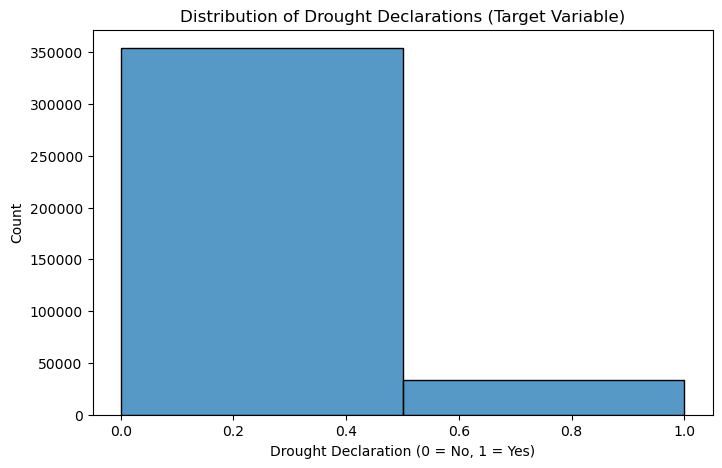

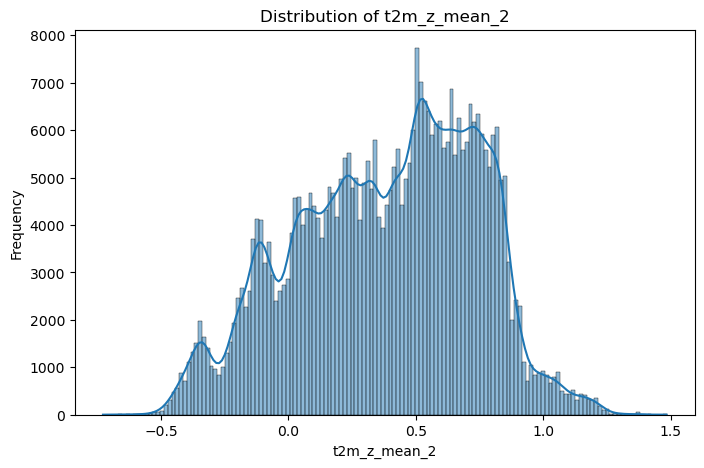

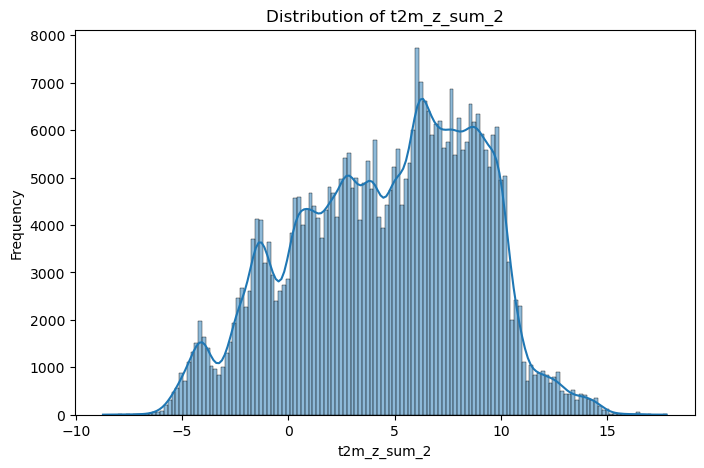

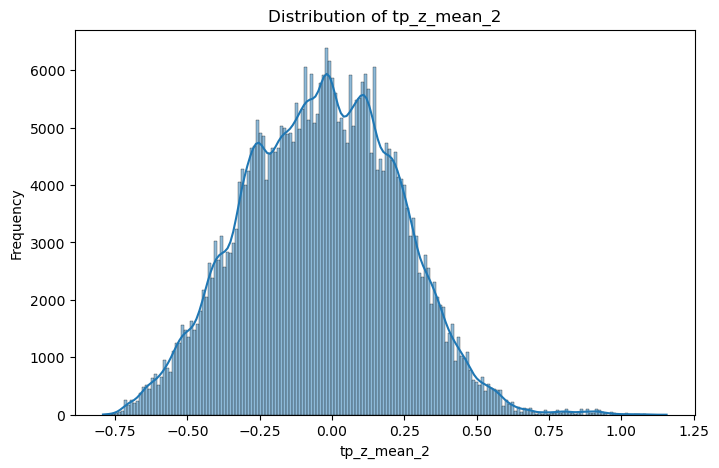

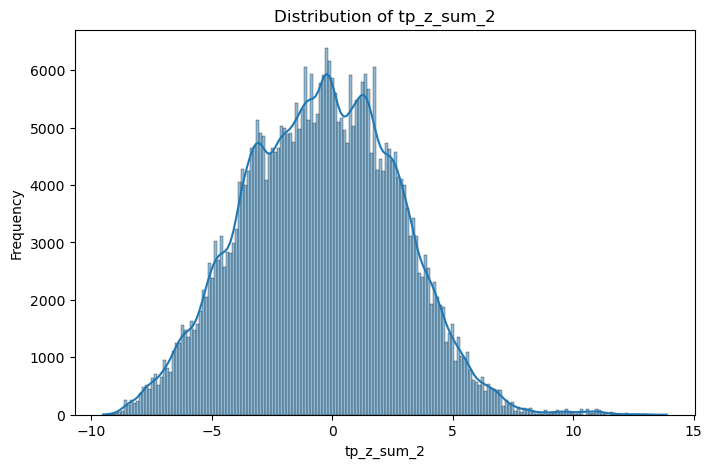

[I 2024-11-01 01:14:32,049] A new study created in memory with name: no-name-813d25f3-7da3-4530-b128-4047d17430c4


          latitude_1    longitude_1         year_1  applied_1     decision_1  \
count  387086.000000  387086.000000  387086.000000   387086.0  387086.000000   
mean       46.380308       2.643289    2011.491297        1.0       0.085531   
std         2.058532       2.353549       6.895176        0.0       0.279671   
min        42.473962      -4.587631    2000.000000        1.0       0.000000   
25%        44.511405       0.684349    2006.000000        1.0       0.000000   
50%        46.532541       2.375800    2011.000000        1.0       0.000000   
75%        48.048391       4.717058    2017.000000        1.0       0.000000   
max        51.063772       8.000078    2023.000000        1.0       1.000000   

       Code Région_1  latitude_rad_1  longitude_rad_1     latitude_2  \
count  387086.000000   387086.000000    387086.000000  387086.000000   
mean       53.217494        0.809489         0.046134      46.380635   
std        25.026886        0.035928         0.041077       2.0

In [26]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Check for Missing Values and Remove if Found
print("Checking for missing values...\n")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])
df.dropna(inplace=True)

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_z_mean_2', 't2m_z_sum_2']
precip_cols = ['tp_z_mean_2', 'tp_z_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df = df.sort_values(by='year_1')
train = df[df['year_1'] < df['year_1'].quantile(0.8)]
test = df[df['year_1'] >= df['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df.columns if '_z_' in col]
X_train = train[weather_features]
y_train = train['decision_1']
X_test = test[weather_features]
y_test = test['decision_1']

# 4. Model Building Using MLP (Neural Network with PyTorch)
# Define Neural Network Class
class DroughtPredictionNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DroughtPredictionNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Set parameters for the neural network
input_size = X_train.shape[1]
hidden_size = 64  # This will be tuned
output_size = 1

# 5. Hyperparameter Tuning Using Optuna
def objective(trial):
    # Hyperparameter Suggestions
    hidden_size = trial.suggest_int('hidden_size', 32, 128)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
    num_epochs = trial.suggest_int('num_epochs', 10, 50)

    # Define Model
    model_nn = DroughtPredictionNN(input_size, hidden_size, output_size)
    optimizer = optim.Adam(model_nn.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()

    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

    # Create DataLoader for training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Training Loop
    model_nn.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model_nn(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Evaluation
    model_nn.eval()
    with torch.no_grad():
        y_probs = model_nn(X_test_tensor).numpy()
        roc_auc = roc_auc_score(y_test, y_probs)
    return roc_auc

# Optimize Hyperparameters
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial:", study.best_trial.params)

# 6. Model Evaluation
# Train the Best Neural Network Model
best_params = study.best_trial.params
model_nn = DroughtPredictionNN(input_size, best_params['hidden_size'], output_size)
optimizer = optim.Adam(model_nn.parameters(), lr=best_params['learning_rate'])
criterion = nn.BCELoss()

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

# Create DataLoader for training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training Loop with Best Parameters
model_nn.train()
for epoch in range(best_params['num_epochs']):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# Make Predictions
y_probs = model_nn(X_test_tensor).detach().numpy()
y_pred = (y_probs > 0.5).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Precision-Recall Curve
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 7. Saving the Model
current_time = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'drought_prediction_nn_model_{current_time}.pth'
torch.save(model_nn.state_dict(), model_filename)
print(f"Neural Network model saved successfully as '{model_filename}'")

# 8. Deployment Considerations
# Load the Model for Future Data Predictions
model_nn = DroughtPredictionNN(input_size, best_params['hidden_size'], output_size)
model_nn.load_state_dict(torch.load(model_filename))
model_nn.eval()
with torch.no_grad():
    new_preds = (model_nn(X_test_tensor).numpy() > 0.5).astype(int)
print("Predictions on new data successfully completed using Neural Network model.")

# 9. Summary Performance for the Best Model
print("Summary Performance for the Best Neural Network Model:")
print("Best Hyperparameters:", best_params)
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Drought', 'Drought']))

# End of Notebook


In [23]:
#!pip install torch